# Guardian ruins parameter analyses 

This notebook is set up to perform analyses on system and body parameters of Guardian ruins known as of 29/Aug/2026.

## Data import and processing

### Import CSV file generated by Seventh Circle

In [1]:
import pandas as pd

input_data = pd.read_csv("data/GuardianLogs-FullRuinsData.csv", dtype={"Materials": "string"}, keep_default_na=False)

#lines = 1
#display(input_data.head(lines).style.set_table_attributes('style="display:block; overflow-x:auto; white-space:nowrap;"'))

### Process DF to parse materials and remove some unnecessary strings

In [2]:
# Element symbols
symbols = {
    "Antimony":"Sb", "Arsenic":"As", "Cadmium":"Cd", "Carbon":"C", "Chromium":"Cr",
    "Germanium":"Ge", "Iron":"Fe", "Manganese":"Mn", "Mercury":"Hg", "Molybdenum":"Mo",
    "Nickel":"Ni", "Niobium":"Nb", "Phosphorus":"P", "Polonium":"Po", "Ruthenium":"Ru",
    "Selenium":"Se", "Sulphur":"S", "Technetium":"Tc", "Tellurium":"Te", "Tin":"Sn",
    "Tungsten":"W", "Vanadium":"V", "Yttrium":"Y", "Zinc":"Zn", "Zirconium":"Zr"
}

# Process imported df to parse elements
processed_data = input_data.drop(columns="Materials").copy()
parsed = processed_data.index.to_series().to_frame("row").join(input_data["Materials"].str.extractall(r"([^:,]+):\s*([\d.]+%)").rename(columns={0:"item", 1:"value"}).reset_index(level=1, drop=True).rename_axis(None))
parsed["item"] = parsed["item"].str.strip().map(symbols)
parsed["value"] = parsed["value"].str.rstrip("%").astype(float)
parsed = parsed.pivot(columns="item", values="value").reindex(columns=symbols.values(), fill_value=0)
parsed.columns = [f"{symbol} (%)" for symbol in parsed.columns]
processed_data = processed_data.join(parsed).fillna(0)

# Rename some columns, remove unnecessary strings, turn booleans into strings
processed_data = processed_data.rename(columns={"Surface Pressure (Atmospheres)": "Surface Pressure (atm)", "Luminosity": "Star Luminosity", "Spectral Class": "Star Spectral Class", "Absolute Magnitude": "Star Absolute Magnitude", "Age": "Star Age (Myr)", "Surface Temperature": "Star Surface Temperature (K)", "Body Radius": "Body Radius (km)", "Gravity": "Gravity (g)"})
processed_data["Parent Subtype"] = processed_data["Parent Subtype"].str.replace(" (Brown dwarf)", "", regex=False).replace("", "n/a")
processed_data["Body Subtype"] = processed_data["Body Subtype"].replace({"High metal content world": "HMC", "Rocky body": "Rocky"})
processed_data["Volcanism"] = processed_data["Volcanism"].replace({"": "n/a", "No volcanism": "No"})
processed_data["Atmosphere"] = processed_data["Atmosphere"].replace("No atmosphere", "none")
processed_data["Tidally Locked"] = processed_data["Tidally Locked"].astype(str)

lines = 10
display(processed_data.head(lines).style.set_properties(**{"white-space": "nowrap"}).set_table_attributes('style="display:block; overflow-x:auto;"'))

,Reference,ID64,System Name,Mod(8),Mass Code,Body,Ruin Index,Site Type,EDx,EDy,EDz,Surface Lattitude,Surface Longitude,Active Monolith Count,Region,Primary Star Type,Star Luminosity,Star Spectral Class,Star Absolute Magnitude,Star Age (Myr),Star Surface Temperature (K),Number of Stars,Body Count,Body Name,Body ID64,Body ID,Body Type,Body Subtype,Tidally Locked,Distance to Arrival,Rotational Period,Semi Major Axis,Arg of Periapsis,Axial Tilt,Orbital Eccentricity,Orbital Inclination,Orbital Period,Orbital Syncronicity,Parent ID,Parent Type,Parent Subtype,Body Radius (km),Earth Masses,Surface Temperature (K),Gravity (g),Body Ice (%),Body Metal (%),Body Rock (%),Volcanism,Atmosphere,Surface Pressure (atm),Orbital Period (days),Terraforming State,Sb (%),As (%),Cd (%),C (%),Cr (%),Ge (%),Fe (%),Mn (%),Hg (%),Mo (%),Ni (%),Nb (%),P (%),Po (%),Ru (%),Se (%),S (%),Tc (%),Te (%),Sn (%),W (%),V (%),Y (%),Zn (%),Zr (%)
0,GR001,3515254557027,Synuefe XR-H d11-102,3,d,1 b,1,β,357.343750,-49.343750,-74.750000,,,,Inner Orion Spur,Star,Vb,F3,3.468063,3600,6914,3,30,Synuefe XR-H d11-102 1 b,468377876501088611,13,Planet,Rocky,False,790.201428,-6.915673,0.017869,6.669092,-1.656497,0.000494,-0.434872,6.915614,13.831287,360291485444196707,Star,Y Star,1121.557875,0.004118,299.691406,0.133059,0,9.535500,90.464500,n/a,none,0.000000,6.915614,Not terraformable,0.000000,2.500295,1.532772,15.913092,0.000000,5.590829,19.738350,8.151737,0.000000,0.000000,14.929262,0.000000,10.187834,0.000000,0.000000,0.000000,18.923960,0.000000,1.448036,0.000000,1.083834,0.000000,0.000000,0.000000,0.000000
1,GR002,9474831951257,IC 2391 Sector GW-V b2-4,1,b,B 1,1,β,587.937500,-51.031250,-38.531250,,,,Inner Orion Spur,Star,Va,M5,9.443909,3334,2730,4,26,IC 2391 Sector GW-V b2-4 B 1,540441430116410777,15,Planet,HMC,True,3279.174588,22.682589,0.085168,156.028121,1.017177,0.000057,0.152069,22.682579,0.000010,144124662907807129,Star,L Star,1754.819875,0.019561,221.964264,0.258167,0,33.612700,66.387300,n/a,none,0.000000,22.682579,Not terraformable,0.000000,0.000000,0.000000,12.852290,9.815071,0.000000,21.824209,9.013175,0.000000,1.425108,16.506918,1.491568,8.228256,0.000000,0.000000,2.392081,15.284036,0.000000,1.167292,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,GR003,3480928373091,IC 2391 Sector ZE-A d101,3,d,C 3,1,α,526.500000,-86.375000,-37.937500,,,,Inner Orion Spur,Star,Vb,F9,4.466400,1680,6081,3,38,IC 2391 Sector ZE-A d101 C 3,1188953782554184035,33,Planet,HMC,True,338662.170400,7.453341,0.040411,321.519329,0.734735,0.004480,0.022454,7.505649,0.052308,144118669004228963,Star,L Star,1504.655750,0.012218,300.084015,0.219327,0,33.658800,66.341200,n/a,none,0.000000,7.505649,Not terraformable,0.000000,0.000000,0.000000,12.631005,9.521257,0.000000,21.170902,8.743367,0.924498,1.382448,16.012783,0.000000,8.086586,0.000000,1.307438,0.000000,15.020880,0.000000,0.000000,0.000000,0.000000,5.198837,0.000000,0.000000,0.000000
3,GR004,4757716439746,Synuefe XO-P c22-17,2,c,C 1,1,β,546.906250,-56.468750,-97.812500,,,,Inner Orion Spur,Star,Va,K9,7.677536,2060,3795,4,38,Synuefe XO-P c22-17 C 1,432350321944007362,12,Planet,HMC,True,1405.517264,6.435756,0.030762,353.467679,-0.347764,0.001164,0.024493,6.435736,0.000020,180148742811259586,Star,L Star,1812.573375,0.021549,244.809494,0.266570,0,33.302900,66.697100,No,none,0.000000,6.435736,Not terraformable,0.000000,0.000000,1.640268,12.488730,9.499548,0.000000,21.122629,8.723431,0.000000,1.379295,15.976273,0.000000,7.995500,0.000000,0.000000,0.000000,14.851686,0.000000,1.135662,0.000000,0.000000,5.186983,0.000000,0.000000,0.000000
4,GR005,4099470772571,Synuefe ZL-J d10-119,3,d,9 b,1,α,834.218750,-51.218750,-154.656250,,,,Inner Orion Spur,Star,VI,F9,4.949051,412,6063,2,49,Synuefe ZL-J d10-119 9 b,1008810416001763675,28,Planet,Rocky,True,1070.654411,2.942806,0.007239,148.283503,0.417828,0.012392,0.066521,2.942773,0.000034,900724024944871771,Planet,Class III gas giant,1299.617375,0.006411,230.213287,0.154268,0,8.859100,91.140900,n/a,none,0.0

## Plots!

### Histogram grid of individual parameters

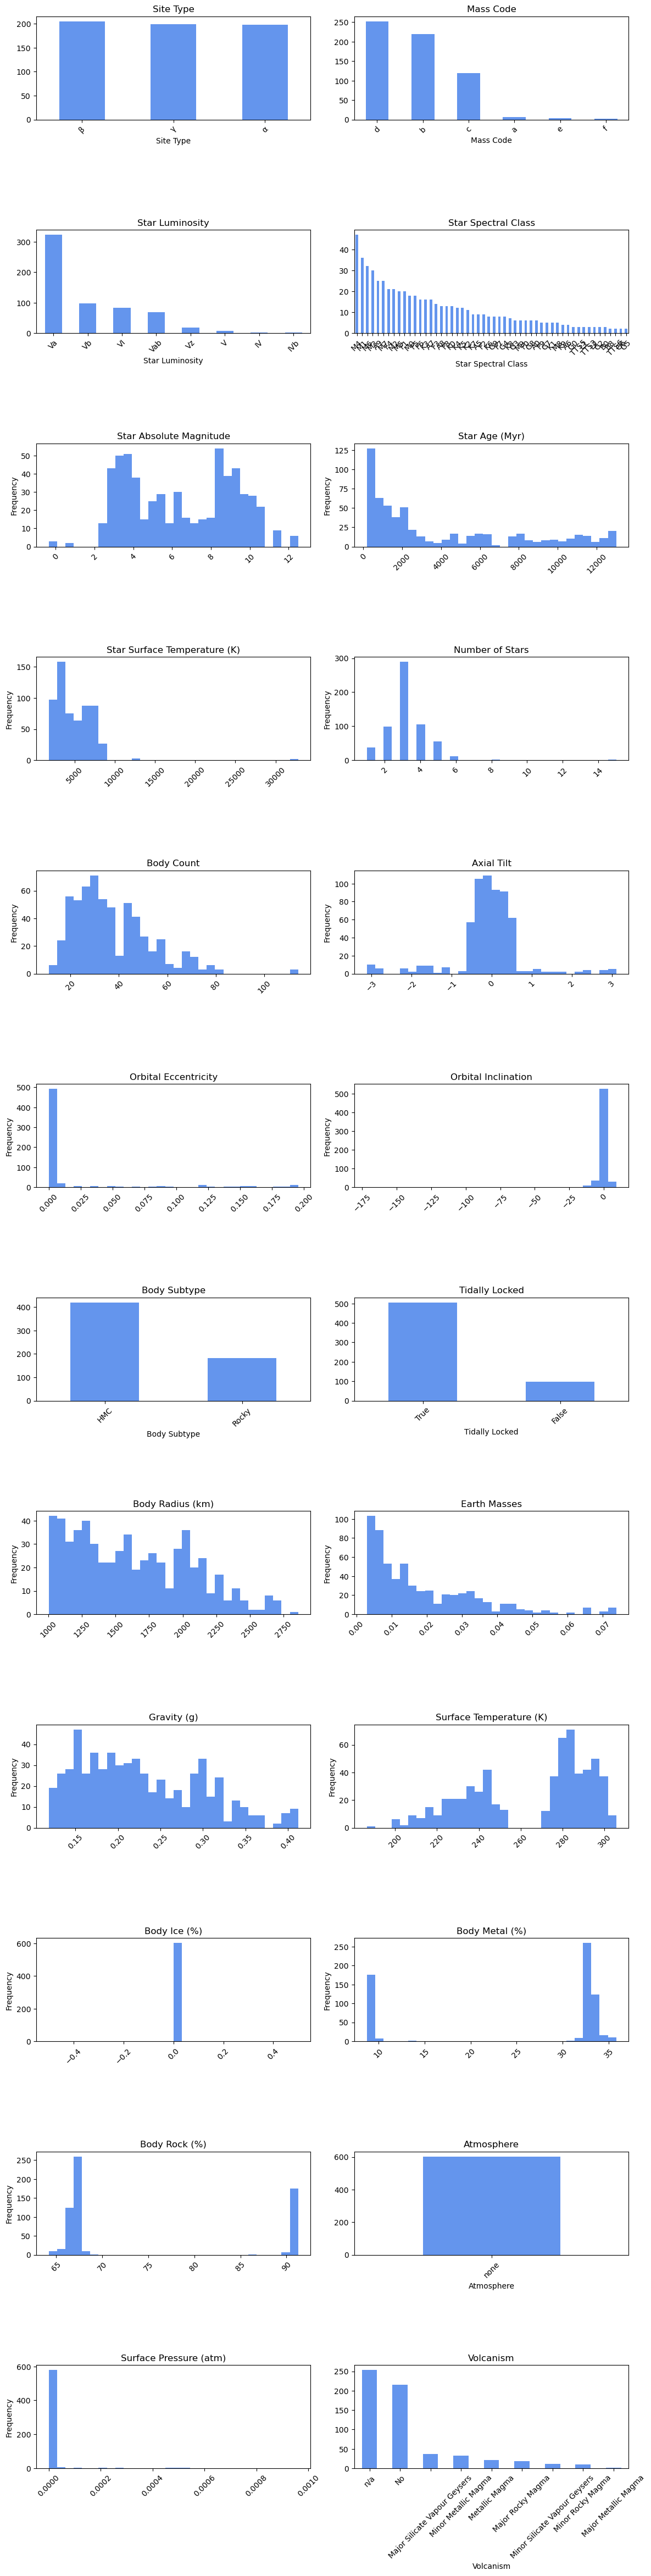

In [34]:
import matplotlib.pyplot as plt

columns = [
    "Site Type", "Mass Code", "Star Luminosity", "Star Spectral Class", "Star Absolute Magnitude",
    "Star Age (Myr)", "Star Surface Temperature (K)", "Number of Stars", "Body Count",
    "Axial Tilt", "Orbital Eccentricity", "Orbital Inclination",
    "Body Subtype", "Tidally Locked", "Body Radius (km)", "Earth Masses",
    "Gravity (g)", "Surface Temperature (K)", "Body Ice (%)", "Body Metal (%)",
    "Body Rock (%)", "Atmosphere", "Surface Pressure (atm)", "Volcanism"
]

fig, axes = plt.subplots(len(columns)//2 + 1, 2, figsize=(12, 2*len(columns)+1))
axes = axes.ravel()

for ax, column in zip(axes, columns):
    if pd.api.types.is_numeric_dtype(processed_data[column]):
        processed_data[column].plot.hist(ax=ax, bins=30, color="cornflowerblue")
    else:
        processed_data[column].value_counts().plot.bar(ax=ax, color="cornflowerblue")
    ax.set_title(column)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

### Body gravity

Min: 0.1186094626
Max: 0.4121033955


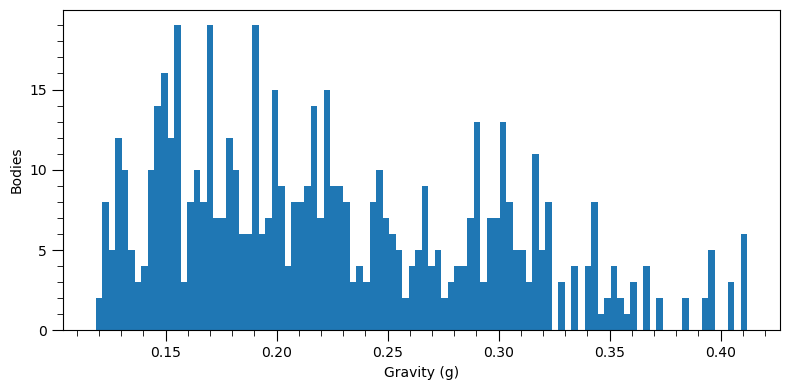

In [4]:
from matplotlib.ticker import MultipleLocator

gravity = pd.to_numeric(processed_data["Gravity (g)"], errors="coerce")

print(f"Min: {gravity.min()}")
print(f"Max: {gravity.max()}")

ax = gravity.plot.hist(bins=100, figsize=(8, 4))
ax.set_xlabel("Gravity (g)")
ax.set_ylabel("Bodies")
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="x", which="major", length=8)
ax.tick_params(axis="x", which="minor", length=4)
ax.tick_params(axis="y", which="major", length=8)
ax.tick_params(axis="y", which="minor", length=4)
plt.tight_layout()
plt.show()

### Axial Tilt

Min: -3.114253
Max: 3.110788


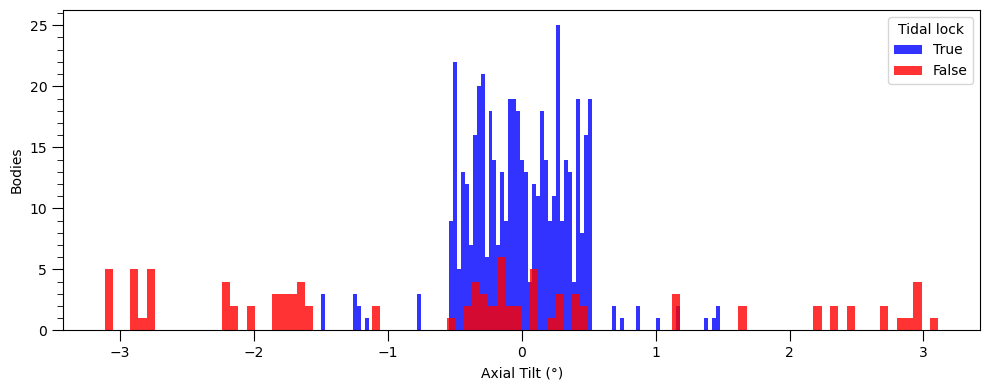

In [38]:
axial_tilt = pd.to_numeric(processed_data["Axial Tilt"], errors="coerce")

print(f"Min: {axial_tilt.min()}")
print(f"Max: {axial_tilt.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(axial_tilt[processed_data["Tidally Locked"] == "True"].dropna(), bins=100, color="blue", alpha=0.8, label="True")
ax.hist(axial_tilt[processed_data["Tidally Locked"] == "False"].dropna(), bins=100, color="red", alpha=0.8, label="False")

ax.set_xlabel("Axial Tilt (°)")
ax.set_ylabel("Bodies")
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Tidal lock")
plt.tight_layout()
plt.show()

Min: -3.114253
Max: 3.110788


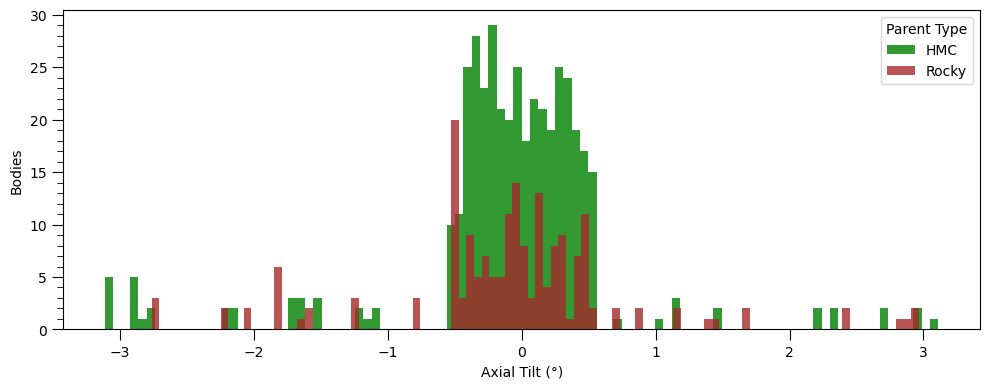

In [43]:
axial_tilt = pd.to_numeric(processed_data["Axial Tilt"], errors="coerce")

print(f"Min: {axial_tilt.min()}")
print(f"Max: {axial_tilt.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(axial_tilt[processed_data["Body Subtype"] == "HMC"].dropna(), bins=100, color="green", alpha=0.8, label="HMC")
ax.hist(axial_tilt[processed_data["Body Subtype"] == "Rocky"].dropna(), bins=100, color="brown", alpha=0.8, label="Rocky")

ax.set_xlabel("Axial Tilt (°)")
ax.set_ylabel("Bodies")
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Parent Type")
plt.tight_layout()
plt.show()

### Tidal lock

Min: 180
Max: 13010


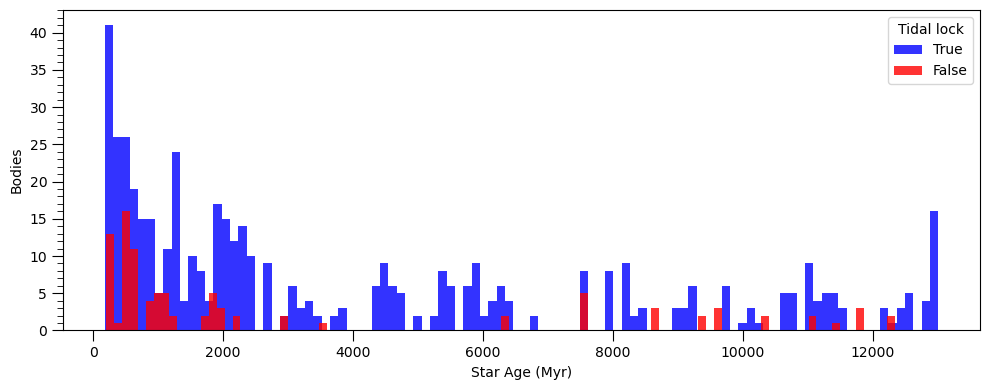

In [49]:
star_age = pd.to_numeric(processed_data["Star Age (Myr)"], errors="coerce")

print(f"Min: {star_age.min()}")
print(f"Max: {star_age.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(star_age[processed_data["Tidally Locked"] == "True"].dropna(), bins=100, color="blue", alpha=0.8, label="True")
ax.hist(star_age[processed_data["Tidally Locked"] == "False"].dropna(), bins=100, color="red", alpha=0.8, label="False")

ax.set_xlabel("Star Age (Myr)")
ax.set_ylabel("Bodies")
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Tidal lock")
plt.tight_layout()
plt.show()

### Surface Temperature

Min: -3.114253
Max: 3.110788


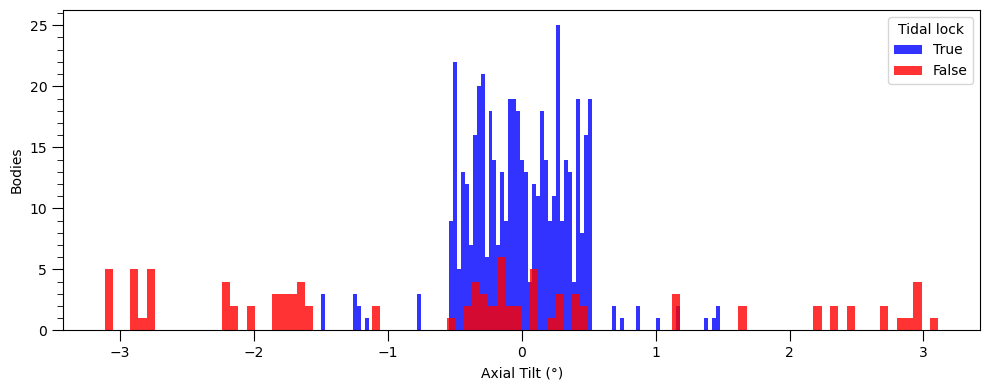

In [37]:
surfT = pd.to_numeric(processed_data["Surface Temperature (K)"], errors="coerce")

print(f"Min: {surfT.min()}")
print(f"Max: {surfT.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(surfT[processed_data["Tidally Locked"] == "True"].dropna(), bins=100, color="blue", alpha=0.8, label="True")
ax.hist(surfT[processed_data["Tidally Locked"] == "False"].dropna(), bins=100, color="red", alpha=0.8, label="False")

ax.set_xlabel("Surface Temperature (K)")
ax.set_ylabel("Bodies")
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Tidal lock")
plt.tight_layout()
plt.show()

Min: 186.424805
Max: 305.600372


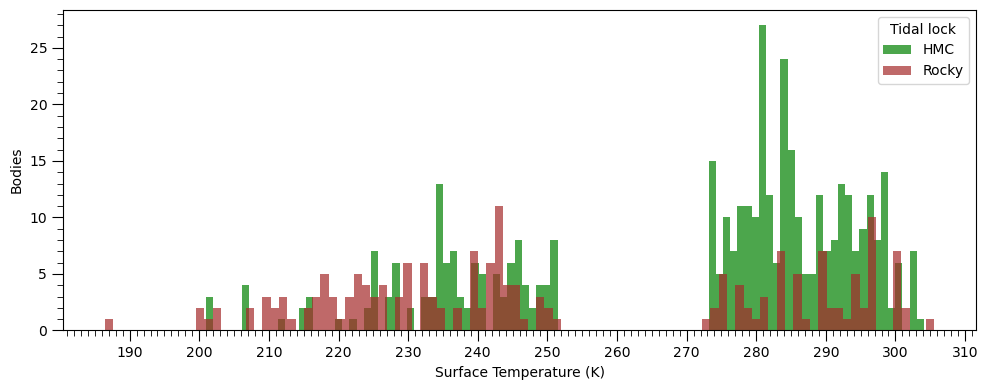

In [7]:
surfT = pd.to_numeric(processed_data["Surface Temperature (K)"], errors="coerce")

print(f"Min: {surfT.min()}")
print(f"Max: {surfT.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(surfT[processed_data["Body Subtype"] == "HMC"].dropna(), bins=100, color="green", alpha=0.7, label="HMC")
ax.hist(surfT[processed_data["Body Subtype"] == "Rocky"].dropna(), bins=100, color="brown", alpha=0.7, label="Rocky")

ax.set_xlabel("Surface Temperature (K)")
ax.set_ylabel("Bodies")
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Tidal lock")
plt.tight_layout()
plt.show()

Min: 186.424805
Max: 305.600372


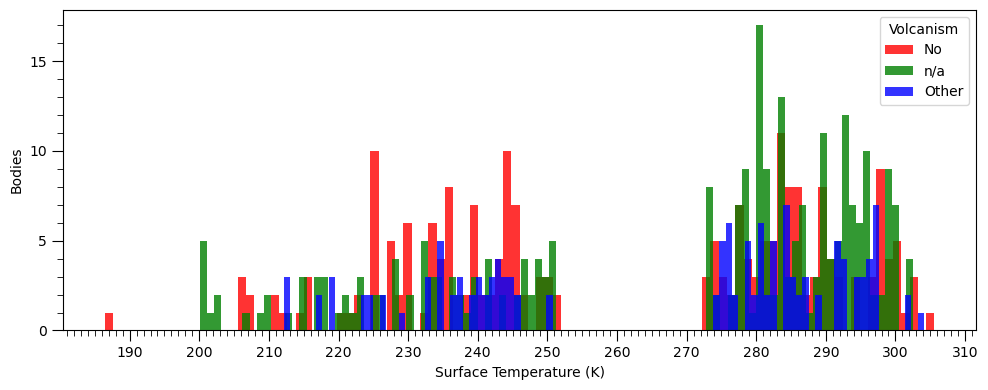

In [8]:
surfT = pd.to_numeric(processed_data["Surface Temperature (K)"], errors="coerce")

print(f"Min: {surfT.min()}")
print(f"Max: {surfT.max()}")

fig, ax = plt.subplots(figsize=(10, 4))

for value, color, label in [("No", "red", "No"), ("n/a", "green", "n/a")]:
    category = processed_data["Volcanism"].eq(value)
    ax.hist(surfT[category].dropna(), bins=100, color=color, alpha=0.8, label=label)

other = ~processed_data["Volcanism"].isin(["No", "n/a"])
ax.hist(surfT[other].dropna(), bins=100, color="blue", alpha=0.8, label="Other")

ax.set_xlabel("Surface Temperature (K)")
ax.set_ylabel("Bodies")
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Volcanism")
plt.tight_layout()
plt.show()

Min: 186.424805
Max: 305.600372


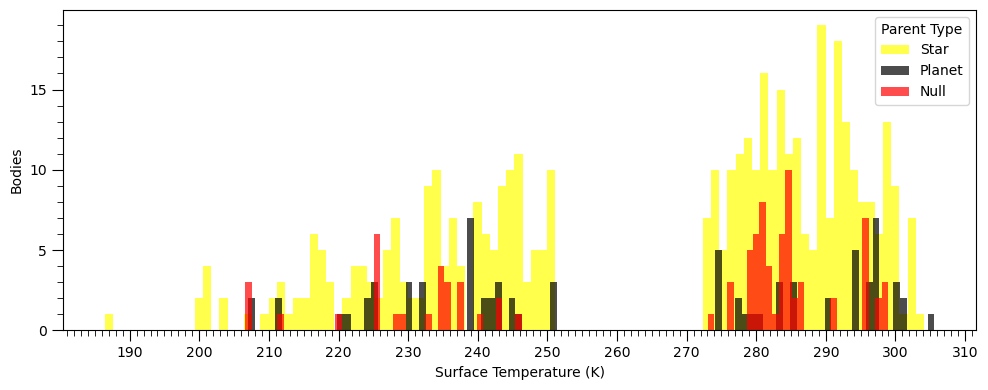

In [33]:
surfT = pd.to_numeric(processed_data["Surface Temperature (K)"], errors="coerce")

print(f"Min: {surfT.min()}")
print(f"Max: {surfT.max()}")

fig, ax = plt.subplots(figsize=(10, 4))

for value, color in [("Star", "yellow"), ("Planet", "black"), ("Null", "red")]:
    category = processed_data["Parent Type"].eq(value)
    ax.hist(surfT[category].dropna(), bins=100, color=color, alpha=0.7, label=value)

ax.set_xlabel("Surface Temperature (K)")
ax.set_ylabel("Bodies")
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Parent Type")
plt.tight_layout()
plt.show()

### Surface Pressure

Min: 0.0
Max: 0.0009608918431


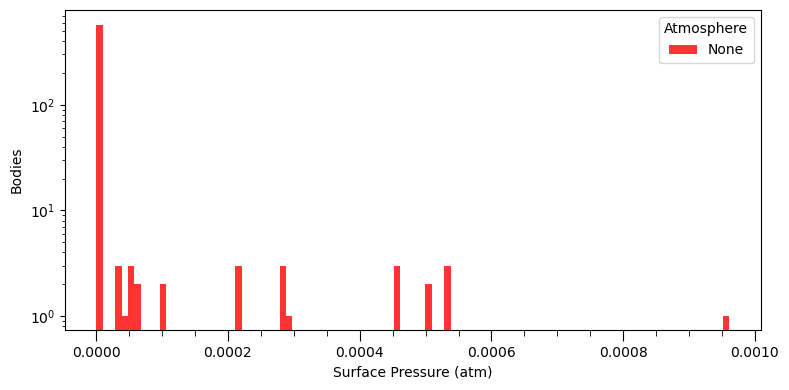

In [9]:
surfP = pd.to_numeric(processed_data["Surface Pressure (atm)"], errors="coerce")

print(f"Min: {surfP.min()}")
print(f"Max: {surfP.max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(surfP[processed_data["Atmosphere"] == "none"].dropna(), bins=100, color="red", alpha=0.8, label="None")

ax.set_xlabel("Surface Pressure (atm)")
ax.set_ylabel("Bodies")
ax.set_yscale("log")
ax.xaxis.set_major_locator(MultipleLocator(0.0002))
ax.xaxis.set_minor_locator(MultipleLocator(0.00005))
ax.tick_params(axis="x", which="major", length=8)
ax.tick_params(axis="x", which="minor", length=4)
ax.legend(title="Atmosphere")
plt.tight_layout()
plt.show()

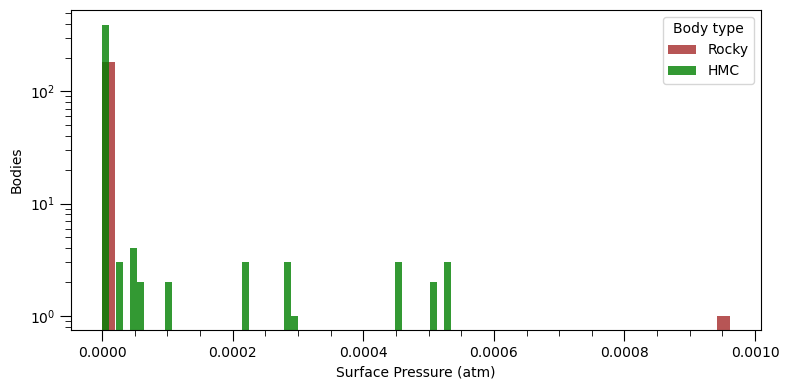

In [10]:
surfP = pd.to_numeric(processed_data["Surface Pressure (atm)"], errors="coerce")
mask = processed_data["Atmosphere"].eq("none")

fig, ax = plt.subplots(figsize=(8, 4))
for subtype, color in {"Rocky": "brown", "HMC": "green"}.items():
    ax.hist(surfP[mask & processed_data["Body Subtype"].eq(subtype)].dropna(), bins=50, color=color, alpha=0.8, label=subtype)

ax.set_xlabel("Surface Pressure (atm)")
ax.set_ylabel("Bodies")
ax.set_yscale("log")
ax.xaxis.set_major_locator(MultipleLocator(0.0002))
ax.xaxis.set_minor_locator(MultipleLocator(0.00005))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Body type")
plt.tight_layout()
plt.show()

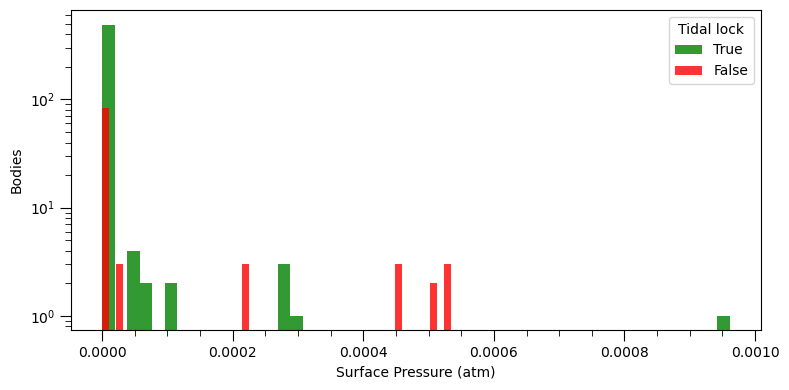

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
for locked, color in [("True", "green"), ("False", "red")]:
    ax.hist(surfP[mask & processed_data["Tidally Locked"].eq(locked)].dropna(), bins=50, color=color, alpha=0.8, label=locked)

ax.set_xlabel("Surface Pressure (atm)")
ax.set_ylabel("Bodies")
ax.set_yscale("log")
ax.xaxis.set_major_locator(MultipleLocator(0.0002))
ax.xaxis.set_minor_locator(MultipleLocator(0.00005))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Tidal lock")
plt.tight_layout()
plt.show()

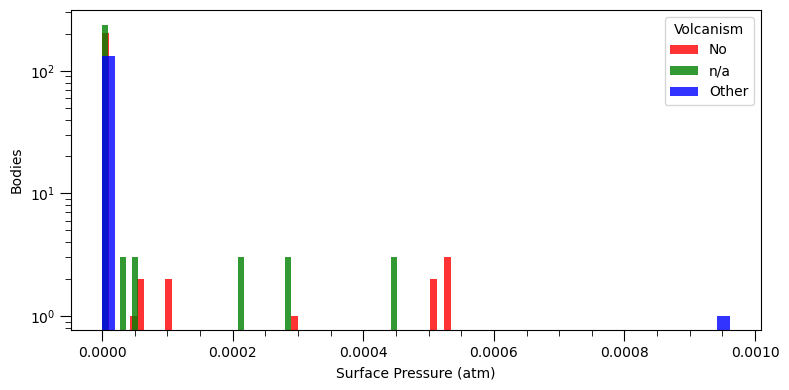

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

for value, color, label in [("No", "red", "No"), ("n/a", "green", "n/a")]:
    category = mask & processed_data["Volcanism"].eq(value)
    ax.hist(surfP[category].dropna(), bins=50, color=color, alpha=0.8, label=label)

other = mask & ~processed_data["Volcanism"].isin(["No", "n/a"])
ax.hist(surfP[other].dropna(), bins=50, color="blue", alpha=0.8, label="Other")

ax.set_xlabel("Surface Pressure (atm)")
ax.set_ylabel("Bodies")
ax.set_yscale("log")
ax.xaxis.set_major_locator(MultipleLocator(0.0002))
ax.xaxis.set_minor_locator(MultipleLocator(0.00005))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Volcanism")
plt.tight_layout()
plt.show()

Min: 0.002968
Max: 0.073801


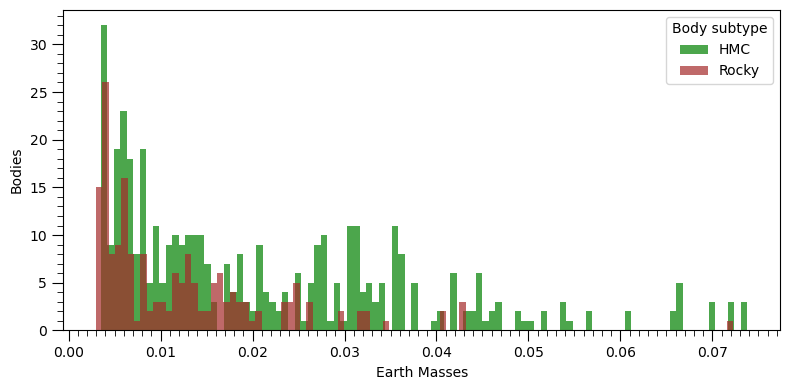

In [13]:
EM = pd.to_numeric(processed_data["Earth Masses"], errors="coerce")
bins = 100

print(f"Min: {EM.min()}")
print(f"Max: {EM.max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(EM[processed_data["Body Subtype"] == "HMC"].dropna(), bins=bins, color="green", alpha=0.7, label="HMC")
ax.hist(EM[processed_data["Body Subtype"] == "Rocky"].dropna(), bins=bins, color="brown", alpha=0.7, label="Rocky")

ax.set_xlabel("Earth Masses")
ax.set_ylabel("Bodies")
ax.xaxis.set_major_locator(MultipleLocator(0.01))
ax.xaxis.set_minor_locator(MultipleLocator(0.001))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis="both", which="major", length=8)
ax.tick_params(axis="both", which="minor", length=4)
ax.legend(title="Body subtype")
plt.tight_layout()
plt.show()

### Scatter plots

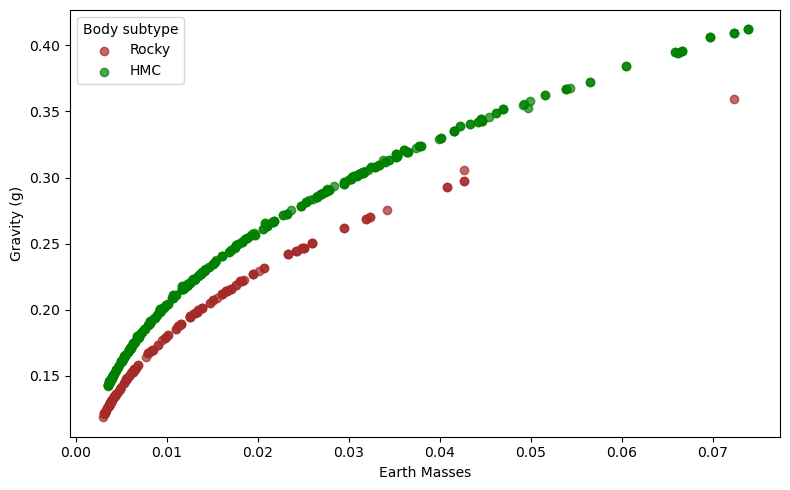

In [14]:
EM = pd.to_numeric(processed_data["Earth Masses"], errors="coerce")
gravity = pd.to_numeric(processed_data["Gravity (g)"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))

for subtype, color in {"Rocky": "brown", "HMC": "green"}.items():
    mask = processed_data["Body Subtype"].eq(subtype)
    ax.scatter(EM[mask], gravity[mask], color=color, alpha=0.7, label=subtype)

ax.set_xlabel("Earth Masses")
ax.set_ylabel("Gravity (g)")
ax.legend(title="Body subtype")
plt.tight_layout()
plt.show()

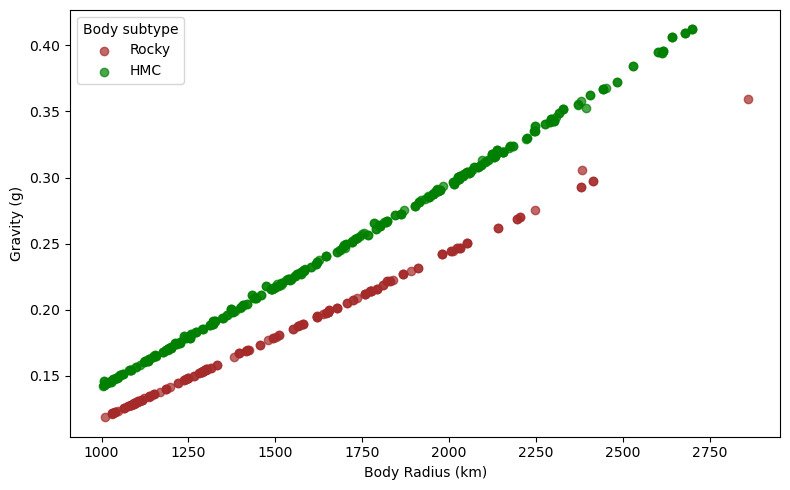

In [15]:
gravity = pd.to_numeric(processed_data["Gravity (g)"], errors="coerce")
radius = pd.to_numeric(processed_data["Body Radius (km)"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))

for subtype, color in {"Rocky": "brown", "HMC": "green"}.items():
    mask = processed_data["Body Subtype"].eq(subtype)
    ax.scatter(radius[mask], gravity[mask], color=color, alpha=0.7, label=subtype)

ax.set_xlabel("Body Radius (km)")
ax.set_ylabel("Gravity (g)")
ax.legend(title="Body subtype")
plt.tight_layout()
plt.show()

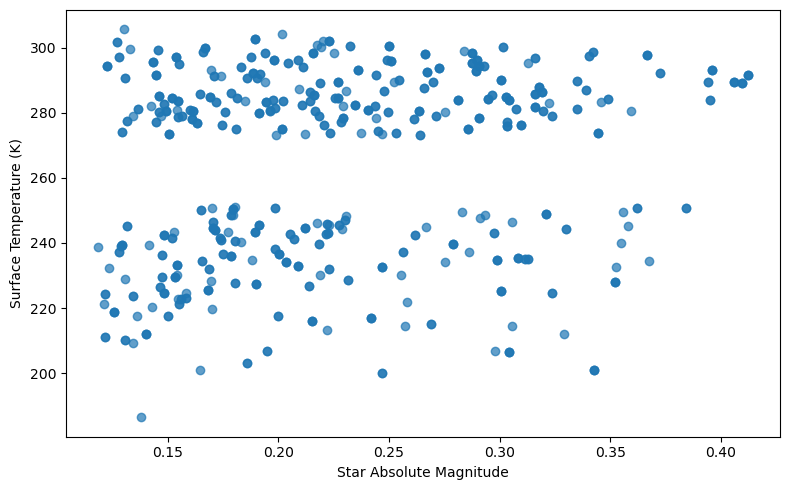

In [16]:
surfT = pd.to_numeric(processed_data["Surface Temperature (K)"], errors="coerce")
absMag = pd.to_numeric(processed_data["Gravity (g)"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(absMag, surfT, alpha=0.7)

ax.set_xlabel("Star Absolute Magnitude")
ax.set_ylabel("Surface Temperature (K)")
plt.tight_layout()
plt.show()

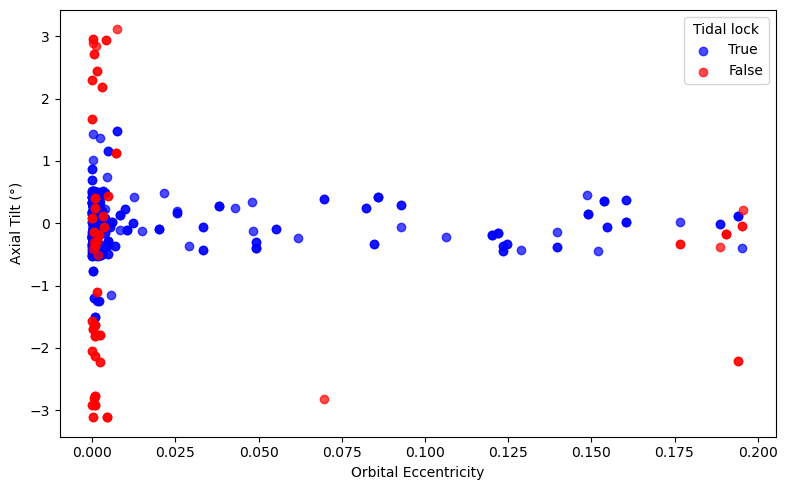

In [46]:
orbital_eccentricity = pd.to_numeric(processed_data["Orbital Eccentricity"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))
for locked, color in [("True", "blue"), ("False", "red")]:
    mask = processed_data["Tidally Locked"].eq(locked)
    ax.scatter(orbital_eccentricity[mask], axial_tilt[mask], color=color, alpha=0.7, label=locked)

ax.set_xlabel("Orbital Eccentricity")
ax.set_ylabel("Axial Tilt (°)")
ax.legend(title="Tidal lock")
plt.tight_layout()
plt.show()

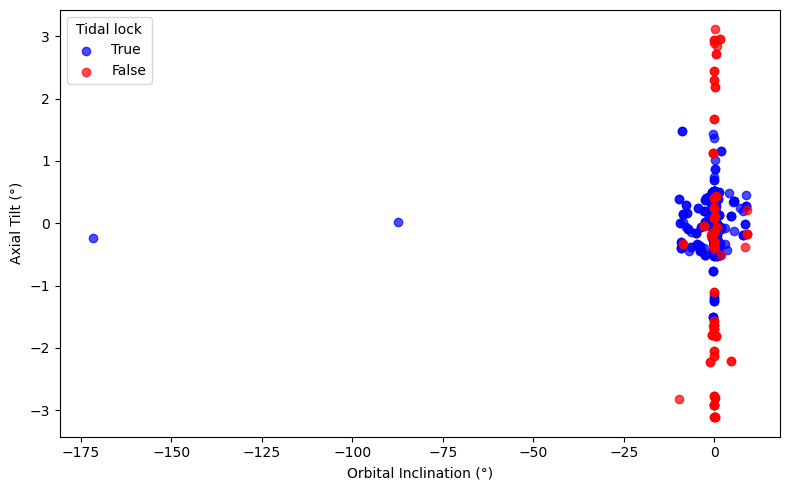

In [47]:
inclination = pd.to_numeric(processed_data["Orbital Inclination"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))
for locked, color in [("True", "blue"), ("False", "red")]:
    mask = processed_data["Tidally Locked"].eq(locked)
    ax.scatter(inclination[mask], axial_tilt[mask], color=color, alpha=0.7, label=locked)

ax.set_xlabel("Orbital Inclination (°)")
ax.set_ylabel("Axial Tilt (°)")
ax.legend(title="Tidal lock")
plt.tight_layout()
plt.show()

### Materials

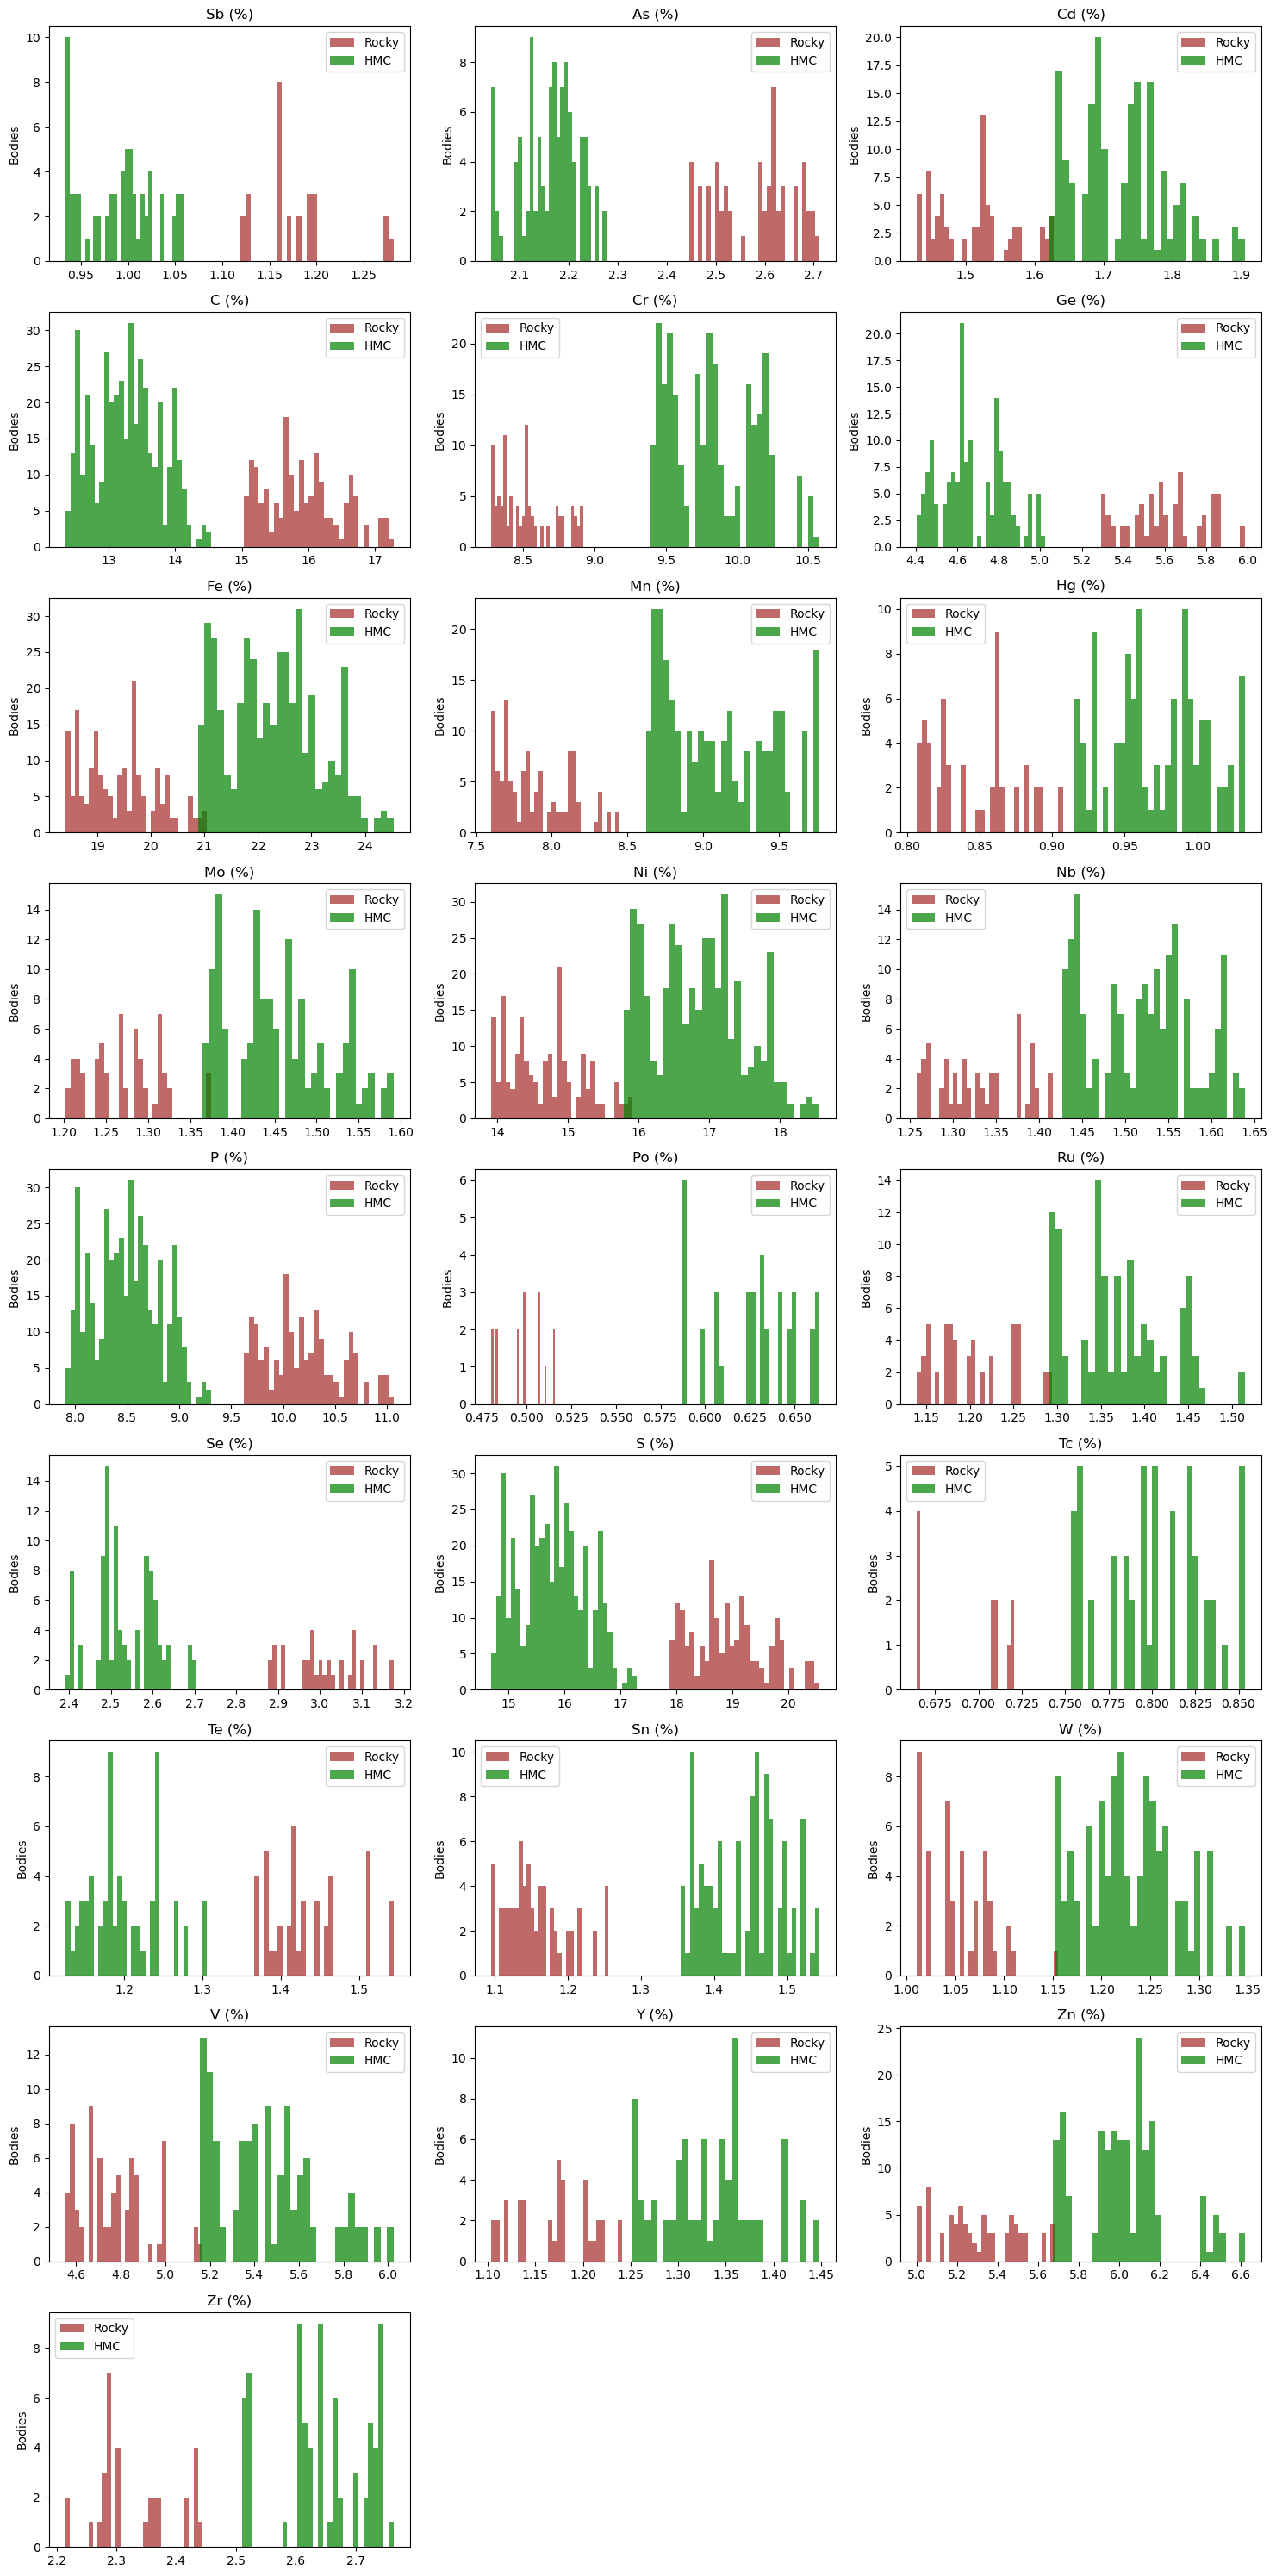

In [19]:
fig, axes = plt.subplots((len(elements) + 2) // 3, 3, figsize=(15, 30))
axes = axes.ravel()

for ax, element in zip(axes, elements):
    values = pd.to_numeric(processed_data[element], errors="coerce")

    for subtype, color in {"Rocky": "brown", "HMC": "green"}.items():
        mask = processed_data["Body Subtype"].eq(subtype) & values.gt(0)
        ax.hist(values[mask], bins=30, color=color, alpha=0.7, label=subtype)

    ax.set_title(element)
    ax.set_ylabel("Bodies")
    ax.legend()

for ax in axes[len(elements):]:
    ax.remove()

plt.tight_layout()
plt.show()